In [1]:
pip install kagglehub pandas seaborn matplotlib scikit-learn

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [2]:
import kagglehub
import os
import pandas as pd

path = kagglehub.dataset_download("mlg-ulb/creditcardfraud")
csv_path = os.path.join(path, "creditcard.csv")
df = pd.read_csv(csv_path)

print("Dataset Loaded Successfully!")
print(df.head())

Dataset Loaded Successfully!
   Time        V1        V2        V3        V4        V5        V6        V7  \
0   0.0 -1.359807 -0.072781  2.536347  1.378155 -0.338321  0.462388  0.239599   
1   0.0  1.191857  0.266151  0.166480  0.448154  0.060018 -0.082361 -0.078803   
2   1.0 -1.358354 -1.340163  1.773209  0.379780 -0.503198  1.800499  0.791461   
3   1.0 -0.966272 -0.185226  1.792993 -0.863291 -0.010309  1.247203  0.237609   
4   2.0 -1.158233  0.877737  1.548718  0.403034 -0.407193  0.095921  0.592941   

         V8        V9  ...       V21       V22       V23       V24       V25  \
0  0.098698  0.363787  ... -0.018307  0.277838 -0.110474  0.066928  0.128539   
1  0.085102 -0.255425  ... -0.225775 -0.638672  0.101288 -0.339846  0.167170   
2  0.247676 -1.514654  ...  0.247998  0.771679  0.909412 -0.689281 -0.327642   
3  0.377436 -1.387024  ... -0.108300  0.005274 -0.190321 -1.175575  0.647376   
4 -0.270533  0.817739  ... -0.009431  0.798278 -0.137458  0.141267 -0.206010   

   

In [3]:
print(df.isnull().sum().max()) 
print(df.info())

0
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     

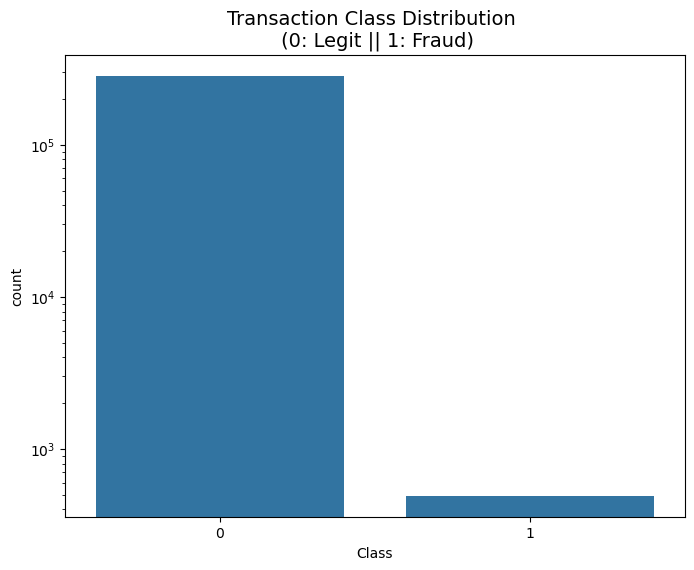

Class
0    284315
1       492
Name: count, dtype: int64


In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.countplot(x='Class', data=df)
plt.title('Transaction Class Distribution \n (0: Legit || 1: Fraud)', fontsize=14)
plt.yscale('log') 
plt.show()

print(df['Class'].value_counts())

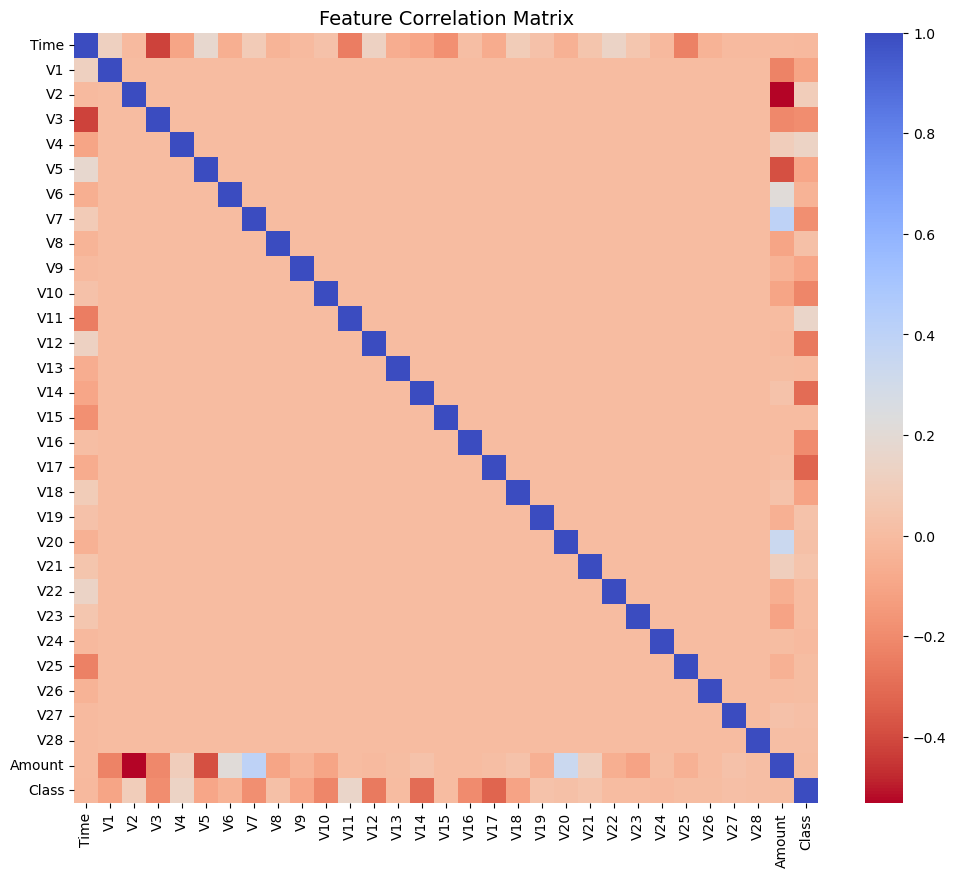

In [5]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
corr = df.corr()
sns.heatmap(corr, cmap='coolwarm_r', annot_kws={'size':20})
plt.title('Feature Correlation Matrix', fontsize=14)
plt.show()

In [6]:
# Scale 'Amount' and 'Time' using RobustScaler
from sklearn.preprocessing import RobustScaler

rob_scaler = RobustScaler()

# Create new columns for scaled data
df['scaled_amount'] = rob_scaler.fit_transform(df['Amount'].values.reshape(-1,1))
df['scaled_time'] = rob_scaler.fit_transform(df['Time'].values.reshape(-1,1))

# Drop the old unscaled columns
df.drop(['Time','Amount'], axis=1, inplace=True)

# Rearrange columns so scaled ones are at the front
scaled_amount = df['scaled_amount']
scaled_time = df['scaled_time']
df.drop(['scaled_amount', 'scaled_time'], axis=1, inplace=True)
df.insert(0, 'scaled_amount', scaled_amount)
df.insert(1, 'scaled_time', scaled_time)

print("Preprocessing Complete. Top 5 rows:")
print(df.head())

Preprocessing Complete. Top 5 rows:
   scaled_amount  scaled_time        V1        V2        V3        V4  \
0       1.783274    -0.994983 -1.359807 -0.072781  2.536347  1.378155   
1      -0.269825    -0.994983  1.191857  0.266151  0.166480  0.448154   
2       4.983721    -0.994972 -1.358354 -1.340163  1.773209  0.379780   
3       1.418291    -0.994972 -0.966272 -0.185226  1.792993 -0.863291   
4       0.670579    -0.994960 -1.158233  0.877737  1.548718  0.403034   

         V5        V6        V7        V8  ...       V20       V21       V22  \
0 -0.338321  0.462388  0.239599  0.098698  ...  0.251412 -0.018307  0.277838   
1  0.060018 -0.082361 -0.078803  0.085102  ... -0.069083 -0.225775 -0.638672   
2 -0.503198  1.800499  0.791461  0.247676  ...  0.524980  0.247998  0.771679   
3 -0.010309  1.247203  0.237609  0.377436  ... -0.208038 -0.108300  0.005274   
4 -0.407193  0.095921  0.592941 -0.270533  ...  0.408542 -0.009431  0.798278   

        V23       V24       V25       V26   

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve, auc
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline
import xgboost as xgb
import numpy as np

# Split data
X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("Train/Test split done.")
print(f"Train shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Train class distribution: {y_train.value_counts()}")
print(f"Test class distribution: {y_test.value_counts()}")

Train/Test split done.
Train shape: (227845, 30), Test shape: (56962, 30)
Train class distribution: Class
0    227451
1       394
Name: count, dtype: int64
Test class distribution: Class
0    56864
1       98
Name: count, dtype: int64


In [8]:
# Apply SMOTE to training data
smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train, y_train)

print("SMOTE applied.")
print(f"Resampled train shape: {X_train_sm.shape}")
print(f"Resampled class distribution: {y_train_sm.value_counts()}")

# Define cost-sensitive parameters
# For fraud detection, FN is costly. Let's assume cost_FN = 100, cost_FP = 1
cost_fn = 100
cost_fp = 1

# Calculate class weights
class_weight = {0: 1, 1: cost_fn / cost_fp}  # weight for minority class higher

# For XGBoost, scale_pos_weight = negative / positive
scale_pos_weight = len(y_train[y_train==0]) / len(y_train[y_train==1])

print(f"Class weight: {class_weight}")
print(f"Scale pos weight: {scale_pos_weight}")

SMOTE applied.
Resampled train shape: (454902, 30)
Resampled class distribution: Class
0    227451
1    227451
Name: count, dtype: int64
Class weight: {0: 1, 1: 100.0}
Scale pos weight: 577.2868020304569


In [9]:
# Decision Tree with class weights
dt = DecisionTreeClassifier(random_state=42, class_weight=class_weight)
dt.fit(X_train_sm, y_train_sm)

# Predictions
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:, 1]

print("Decision Tree trained.")
print("Classification Report:")
print(classification_report(y_test, y_pred_dt))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_dt))

Decision Tree trained.
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.44      0.80      0.56        98

    accuracy                           1.00     56962
   macro avg       0.72      0.90      0.78     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56763   101]
 [   20    78]]


In [10]:
pip install xgboost

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


In [11]:
# XGBoost with scale_pos_weight
xgb_model = xgb.XGBClassifier(random_state=42, scale_pos_weight=scale_pos_weight, eval_metric='logloss')
xgb_model.fit(X_train_sm, y_train_sm)

# Predictions
y_pred_xgb = xgb_model.predict(X_test)
y_prob_xgb = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost trained.")
print("Classification Report:")
print(classification_report(y_test, y_pred_xgb))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_xgb))

XGBoost trained.
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.46      0.85      0.59        98

    accuracy                           1.00     56962
   macro avg       0.73      0.92      0.80     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56766    98]
 [   15    83]]


In [12]:
# Neural Network (MLP) - MLPClassifier doesn't support class_weight, using balanced data from SMOTE
mlp = MLPClassifier(random_state=42, max_iter=500, hidden_layer_sizes=(100, 50))
mlp.fit(X_train_sm, y_train_sm)

# Predictions
y_pred_mlp = mlp.predict(X_test)
y_prob_mlp = mlp.predict_proba(X_test)[:, 1]

print("Neural Network trained.")
print("Classification Report:")
print(classification_report(y_test, y_pred_mlp))
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred_mlp))

Neural Network trained.
Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00     56864
           1       0.72      0.85      0.78        98

    accuracy                           1.00     56962
   macro avg       0.86      0.92      0.89     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56832    32]
 [   15    83]]


In [13]:
import pickle

# Save the trained models
with open('decision_tree_model.pkl', 'wb') as f:
    pickle.dump(dt, f)

with open('xgboost_model.pkl', 'wb') as f:
    pickle.dump(xgb_model, f)

with open('neural_network_model.pkl', 'wb') as f:
    pickle.dump(mlp, f)

# Also save the scaler for preprocessing
with open('scaler.pkl', 'wb') as f:
    pickle.dump(rob_scaler, f)

print("Models and scaler saved as pickle files.")

Models and scaler saved as pickle files.
